# Creating data loaders
### Use features will include punctuation in the dataset while not using them will remove them
### This will enable us to compare whether punctuation features do help

In [2]:
import pandas as pd
import torch
import string
from torch.utils.data import TensorDataset, DataLoader
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def remove_punctuation(text):
    return str(text).translate(str.maketrans('', '', string.punctuation))

def loaders(filename, use_features=True, n=25000, batch_size=16, max_length=128, random_state=42):
    df_full = pd.read_csv(filename)
    df = df_full.sample(n=n, random_state=random_state).reset_index(drop=True)

    train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=random_state)
    train_df, val_df = train_test_split(train_val_df, test_size=0.125, random_state=random_state)

    if not use_features:
        train_df = train_df.copy()
        val_df   = val_df.copy()
        test_df  = test_df.copy()

        train_df['comment'] = train_df['comment'].apply(remove_punctuation)
        val_df['comment']   = val_df['comment'].apply(remove_punctuation)
        test_df['comment']  = test_df['comment'].apply(remove_punctuation)

    tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

    def encode(split_df):
        return tokenizer(
            split_df['comment'].astype(str).tolist(),
            truncation=True, padding='max_length', max_length=max_length, return_tensors='pt'
        )

    train_encodings = encode(train_df)
    val_encodings   = encode(val_df)
    test_encodings  = encode(test_df)

    train_labels = torch.tensor(train_df['label'].values, dtype=torch.long)
    val_labels   = torch.tensor(val_df['label'].values,   dtype=torch.long)
    test_labels  = torch.tensor(test_df['label'].values,  dtype=torch.long)

    def make_loader(encodings, labels, shuffle, batch_size=16):
      ds = TensorDataset(encodings['input_ids'], encodings['attention_mask'], labels)
      return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    train_loader = make_loader(train_encodings, train_labels, shuffle=True)
    val_loader   = make_loader(val_encodings,   val_labels,   shuffle=False)
    test_loader  = make_loader(test_encodings,  test_labels,  shuffle=False)

    print(f"[{'With' if use_features else 'Without'} Punctuation] {filename}")
    print(f"  Train: {len(train_loader)} batches | Val: {len(val_loader)} | Test: {len(test_loader)}\n")

    return train_loader, val_loader, test_loader

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# RoBERTa Model

In [3]:
# RoBERTa Model

import torch.nn as nn
from transformers import RobertaModel

class RobertaWithFeatures(nn.Module):
    def __init__(self, num_classes=2):
        super(RobertaWithFeatures, self).__init__()
        self.roberta = RobertaModel.from_pretrained('roberta-base')
        hidden = self.roberta.config.hidden_size

        self.drop = nn.Dropout(0.3)
        self.classifier = nn.Sequential(
            nn.Linear(hidden, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        output = self.roberta(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
        hidden_states = output.hidden_states
        last_4 = torch.stack(hidden_states[-4:], dim=0).mean(0)

        mask = attention_mask.unsqueeze(-1).float()
        pooled = (last_4 * mask).sum(1) / mask.sum(1)
        pooled = self.drop(pooled)

        return self.classifier(pooled)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Defining Training and Testing Loop Functions

In [4]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import gc
import torch.nn.functional as F

def train_model(model, train_loader, val_loader, model_name="model", epochs=3, patience=2):
    # Using standard learning rates for RoBERTa fine-tuning
    optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=100,
        num_training_steps=len(train_loader) * epochs
    )

    train_losses, val_losses, val_accuracies = [], [], []
    best_val_loss = float('inf')
    epochs_no_improve = 0
    save_path = f"best_{model_name}.pt"

    gc.collect()
    torch.cuda.empty_cache()
    print(f"Starting training: {model_name}\n")

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for i, batch in enumerate(train_loader):
            input_ids, attention_mask, labels = [x.to(device) for x in batch]

            optimizer.zero_grad()
            logits = model(input_ids=input_ids, attention_mask=attention_mask)

            loss = F.cross_entropy(logits, labels)

            loss.backward()
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            if i % 100 == 0:
                print(f"  -> Batch {i}/{len(train_loader)}...")

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f"*** Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} ***\n")

        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids, attention_mask, labels = [x.to(device) for x in batch]
                logits = model(input_ids=input_ids, attention_mask=attention_mask)

                val_loss += F.cross_entropy(logits, labels).item()

                _, preds = torch.max(logits, dim=1)
                correct += torch.sum(preds == labels).item()
                total += labels.size(0)

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = correct / total
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_accuracy)
        print(f"*** Epoch {epoch+1}/{epochs} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f} ***\n")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            epochs_no_improve = 0
            print(f"  -> Improved, model saved.\n")
        else:
            epochs_no_improve += 1
            print(f"  -> No improvement ({epochs_no_improve}/{patience})\n")
            if epochs_no_improve >= patience:
                print("Early stopping — loading best model.")
                model.load_state_dict(torch.load(save_path, weights_only=True))
                break

    return model, train_losses, val_losses, val_accuracies

In [5]:
def evaluate_model(model, test_loader):
    model.eval()
    test_loss, correct, total = 0, 0, 0
    all_labels, all_preds = [], []

    with torch.no_grad():
        for batch in test_loader:
            input_ids, attention_mask, labels = [x.to(device) for x in batch]

            logits = model(input_ids=input_ids, attention_mask=attention_mask)

            test_loss += F.cross_entropy(logits, labels).item()

            _, preds = torch.max(logits, dim=1)
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())

    avg_loss = test_loss / len(test_loader)
    accuracy = correct / total
    print(f"*** Test Loss: {avg_loss:.4f} | Accuracy: {accuracy * 100:.4f}% ***\n")

    return avg_loss, accuracy, all_labels, all_preds

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Training and Testing on Baseline Model (without any punctuation features)

In [6]:
baseline_train_loader, baseline_val_loader, baseline_test_loader = loaders(
    "merged_data.csv", use_features=False
)

baseline_model = RobertaWithFeatures().to(device)


print("Training Loop of Model WITHOUT Punctuation Features")
baseline_model, baseline_train_losses, baseline_val_losses, baseline_val_accs = train_model(
    baseline_model, baseline_train_loader, baseline_val_loader, model_name="baseline"
)

[Without Punctuation] merged_data.csv
  Train: 1094 batches | Val: 157 | Test: 313



Loading weights: 100%|██████████| 197/197 [00:00<00:00, 10870.08it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Loop of Model WITHOUT Punctuation Features
Starting training: baseline

  -> Batch 0/1094...
  -> Batch 100/1094...
  -> Batch 200/1094...
  -> Batch 300/1094...
  -> Batch 400/1094...
  -> Batch 500/1094...
  -> Batch 600/1094...
  -> Batch 700/1094...
  -> Batch 800/1094...
  -> Batch 900/1094...
  -> Batch 1000/1094...
*** Epoch 1/3 | Train Loss: 0.6866 ***

*** Epoch 1/3 | Val Loss: 0.6652 | Val Acc: 0.6000 ***

  -> Improved, model saved.

  -> Batch 0/1094...
  -> Batch 100/1094...
  -> Batch 200/1094...
  -> Batch 300/1094...
  -> Batch 400/1094...
  -> Batch 500/1094...
  -> Batch 600/1094...
  -> Batch 700/1094...
  -> Batch 800/1094...
  -> Batch 900/1094...
  -> Batch 1000/1094...
*** Epoch 2/3 | Train Loss: 0.6597 ***

*** Epoch 2/3 | Val Loss: 0.6479 | Val Acc: 0.6148 ***

  -> Improved, model saved.

  -> Batch 0/1094...
  -> Batch 100/1094...
  -> Batch 200/1094...
  -> Batch 300/1094...
  -> Batch 400/1094...
  -> Batch 500/1094...
  -> Batch 600/1094...
  -> B

# Graphs for baseline RoBERTa Model WITHOUT Punctuation Features

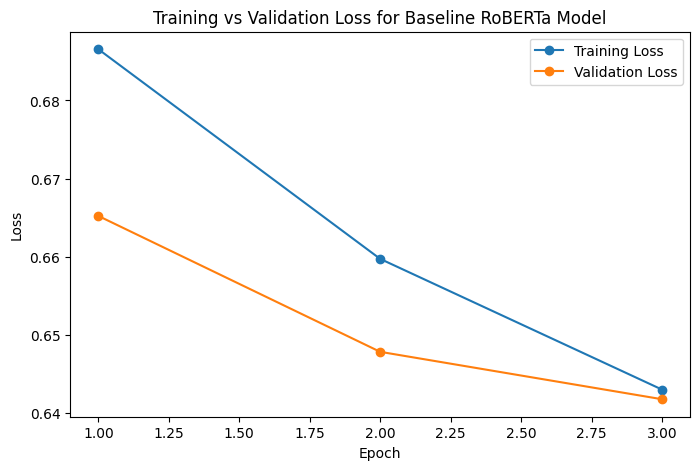

In [7]:
# Training VS Validation loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(baseline_train_losses)+1), baseline_train_losses, marker='o', label = 'Training Loss')
plt.plot(range(1, len(baseline_val_losses)+1), baseline_val_losses, marker='o', label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss for Baseline RoBERTa Model')
plt.legend()
plt.savefig('baseline_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

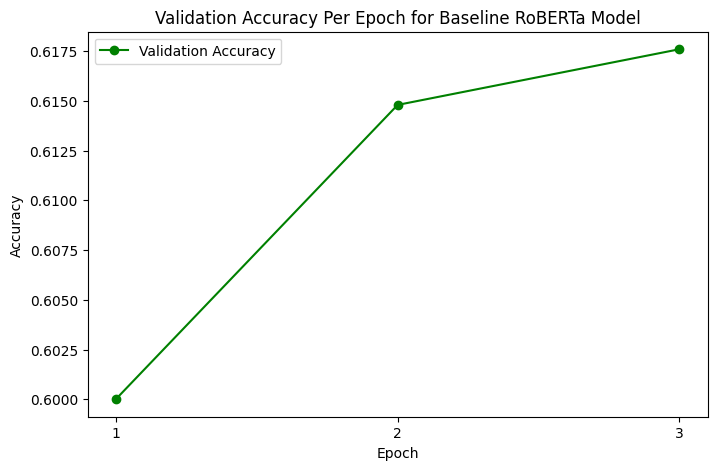

In [8]:
# Validation Accuracy Per Epoch
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(baseline_val_accs)+1), baseline_val_accs, marker='o', color='green', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Per Epoch for Baseline RoBERTa Model')
plt.xticks(range(1, len(baseline_val_accs)+1))
plt.legend()
plt.savefig('baseline_val_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

Evaluation of Model WITHOUT Punctuation Features
*** Test Loss: 0.6422 | Accuracy: 62.4600% ***



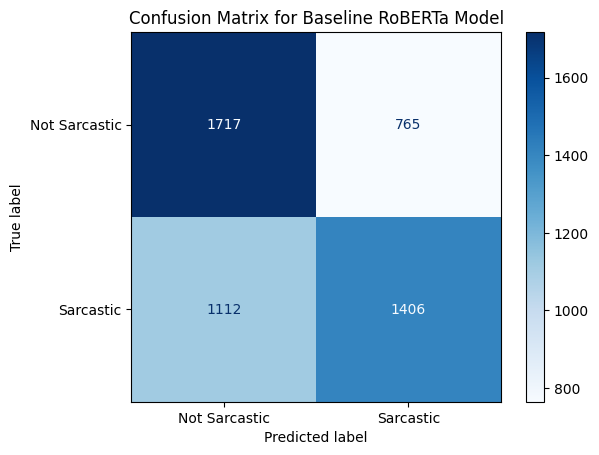

In [9]:
# Confusion Matrix + Evaluation of Model

print("Evaluation of Model WITHOUT Punctuation Features")
baseline_loss, baseline_acc, baseline_labels, baseline_preds = evaluate_model(baseline_model, baseline_test_loader)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(baseline_labels, baseline_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Sarcastic', 'Sarcastic'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Baseline RoBERTa Model')
plt.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Training and testing with RoBERTa model WITH punctuation features

In [7]:
adv_train_loader, adv_val_loader, adv_test_loader = loaders(
    "merged_data.csv", use_features=True
)

adv_model = RobertaWithFeatures().to(device)

print("Training Loop for Model WITH Punctuation")
adv_model, train_losses, val_losses, val_accs = train_model(
    adv_model, adv_train_loader, adv_val_loader, model_name="full"
)

[With Punctuation] merged_data.csv
  Train: 1094 batches | Val: 157 | Test: 313



Loading weights: 100%|██████████| 197/197 [00:00<00:00, 9823.89it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Loop for Model WITH Punctuation
Starting training: full

  -> Batch 0/1094...
  -> Batch 100/1094...
  -> Batch 200/1094...
  -> Batch 300/1094...
  -> Batch 400/1094...
  -> Batch 500/1094...
  -> Batch 600/1094...
  -> Batch 700/1094...
  -> Batch 800/1094...
  -> Batch 900/1094...
  -> Batch 1000/1094...
*** Epoch 1/3 | Train Loss: 0.6891 ***

*** Epoch 1/3 | Val Loss: 0.6802 | Val Acc: 0.5624 ***

  -> Improved, model saved.

  -> Batch 0/1094...
  -> Batch 100/1094...
  -> Batch 200/1094...
  -> Batch 300/1094...
  -> Batch 400/1094...
  -> Batch 500/1094...
  -> Batch 600/1094...
  -> Batch 700/1094...
  -> Batch 800/1094...
  -> Batch 900/1094...
  -> Batch 1000/1094...
*** Epoch 2/3 | Train Loss: 0.6599 ***

*** Epoch 2/3 | Val Loss: 0.6337 | Val Acc: 0.6556 ***

  -> Improved, model saved.

  -> Batch 0/1094...
  -> Batch 100/1094...
  -> Batch 200/1094...
  -> Batch 300/1094...
  -> Batch 400/1094...
  -> Batch 500/1094...
  -> Batch 600/1094...
  -> Batch 700/1094..

# Graphs for baseline RoBERTa Model WITH Punctuation Features

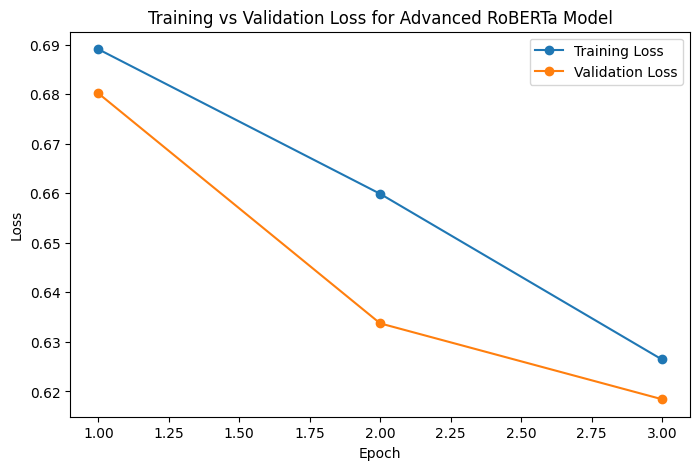

In [8]:
# Training VS Validation loss curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label = 'Training Loss')
plt.plot(range(1, len(val_losses)+1), val_losses, marker='o', label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss for Advanced RoBERTa Model')
plt.legend()
plt.savefig('advanced_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

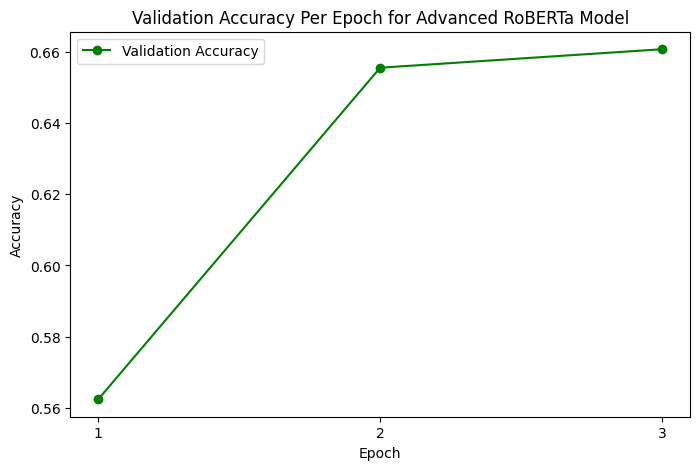

In [9]:
# Validation Accuracy Per Epoch
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(val_accs)+1), val_accs, marker='o', color='green', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Validation Accuracy Per Epoch for Advanced RoBERTa Model')
plt.xticks(range(1, len(val_accs)+1))
plt.legend()
plt.savefig('advanced_val_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

Evaluation of Model WITHOUT Punctuation Features
*** Test Loss: 0.6183 | Accuracy: 65.1000% ***



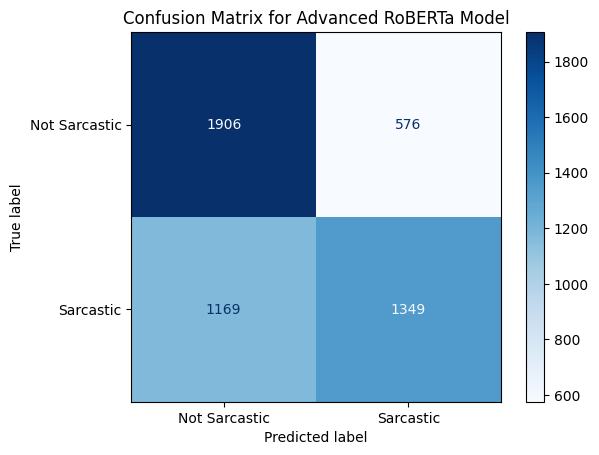

In [10]:
# Confusion Matrix + Evaluation of Model

print("Evaluation of Model WITH Punctuation Features")
adv_loss, adv_acc, adv_labels, adv_preds = evaluate_model(adv_model, adv_test_loader)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(adv_labels, adv_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Sarcastic', 'Sarcastic'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix for Advanced RoBERTa Model')
plt.savefig('advanced_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

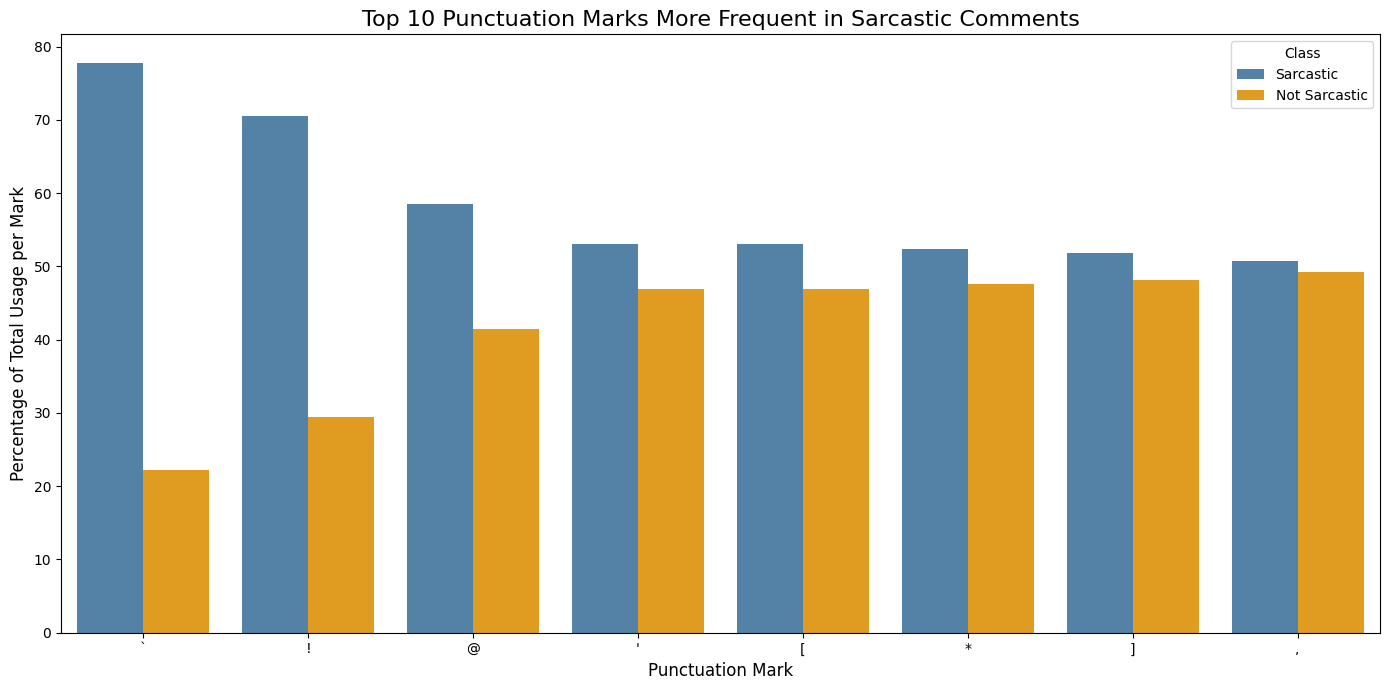

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import string
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/merged_data.csv").sample(n=25000, random_state=42).reset_index(drop=True)

punctuations = string.punctuation
for p in punctuations:
    df[p] = df['comment'].astype(str).apply(lambda x: x.count(p))

means = df.groupby('label')[list(punctuations)].mean()

total = means.loc[0] + means.loc[1]
total = total.replace(0, 1e-9)

sarc_pct = (means.loc[1] / total) * 100
non_sarc_pct = (means.loc[0] / total) * 100

plot_df = pd.DataFrame({'Sarcastic': sarc_pct, 'Not Sarcastic': non_sarc_pct})
plot_df = plot_df[plot_df['Sarcastic'] > plot_df['Not Sarcastic']]
plot_df['gap'] = plot_df['Sarcastic'] - plot_df['Not Sarcastic']
plot_df = plot_df.nlargest(10, 'gap').drop(columns=['gap'])

plot_df = plot_df.reset_index().melt(id_vars='index', var_name='Class', value_name='Percentage')

plt.figure(figsize=(14, 7))
sns.barplot(data=plot_df, x='index', y='Percentage', hue='Class', palette=['steelblue', 'orange'])

plt.title('Top 10 Punctuation Marks More Frequent in Sarcastic Comments', fontsize=16)
plt.ylabel('Percentage of Total Usage per Mark', fontsize=12)
plt.xlabel('Punctuation Mark', fontsize=12)
plt.tight_layout()
plt.show()